In [1]:
# importing libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import iqr

In [2]:
df = pd.read_csv("Zara_Sales_Analysis.csv", sep=";")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252 entries, 0 to 251
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Product ID        252 non-null    int64  
 1   Product Position  252 non-null    object 
 2   Promotion         252 non-null    object 
 3   Product Category  252 non-null    object 
 4   Seasonal          252 non-null    object 
 5   Sales Volume      252 non-null    int64  
 6   brand             252 non-null    object 
 7   url               252 non-null    object 
 8   sku               252 non-null    object 
 9   name              251 non-null    object 
 10  description       250 non-null    object 
 11  price             252 non-null    float64
 12  currency          252 non-null    object 
 13  scraped_at        252 non-null    object 
 14  terms             252 non-null    object 
 15  section           252 non-null    object 
dtypes: float64(1), int64(2), object(13)
memory u

In [3]:
#Loading first 10 rows to understand the data
print(df.head(10))

   Product ID Product Position Promotion Product Category Seasonal  \
0      185102            Aisle        No         Clothing       No   
1      188771            Aisle        No         Clothing       No   
2      180176          End-cap       Yes         Clothing      Yes   
3      112917            Aisle       Yes         Clothing      Yes   
4      192936          End-cap        No         Clothing      Yes   
5      117590          End-cap        No         Clothing       No   
6      189118   Front of Store       Yes         Clothing      Yes   
7      182157            Aisle        No         Clothing       No   
8      141861            Aisle       Yes         Clothing      Yes   
9      137121            Aisle        No         Clothing      Yes   

   Sales Volume brand                                                url  \
0          2823  Zara  https://www.zara.com/us/en/basic-puffer-jacket...   
1           654  Zara  https://www.zara.com/us/en/tuxedo-jacket-p0889...   
2

In [4]:
# Analyzing variety of data in dataset
df.nunique()

Product ID          252
Product Position      3
Promotion             2
Product Category      1
Seasonal              2
Sales Volume        234
brand                 1
url                 228
sku                 228
name                194
description         221
price                28
currency              1
scraped_at          229
terms                 5
section               2
dtype: int64

In [5]:
# Reviewing duplicated skus
df_duplicated_skus = df[df.duplicated(subset="sku", keep=False)].sort_values(by="sku")
print(df_duplicated_skus.head(6))

     Product ID Product Position Promotion Product Category Seasonal  \
244      118985            Aisle        No         Clothing      Yes   
125      183825            Aisle       Yes         Clothing      Yes   
242      177771          End-cap       Yes         Clothing      Yes   
123      183537   Front of Store       Yes         Clothing      Yes   
110      168571            Aisle        No         Clothing       No   
229      139967          End-cap        No         Clothing       No   

     Sales Volume brand                                                url  \
244           694  Zara  https://www.zara.com/us/en/basic-knit-sweater-...   
125          2989  Zara  https://www.zara.com/us/en/plaid-tie-dye-overs...   
242          1764  Zara  https://www.zara.com/us/en/contrast-topstitchi...   
123          2434  Zara  https://www.zara.com/us/en/paint-print-overshi...   
110          1778  Zara  https://www.zara.com/us/en/pocket-overshirt-p0...   
229          2634  Zara  ht

## Data Cleaning and preparation

In [6]:
# Renaming all columns names to statdard format
df.columns = df.columns.str.lower()
df['name'] = df['name'].str.lower()
df['section'] = df['section'].str.lower()

In [7]:
df.columns

Index(['product id', 'product position', 'promotion', 'product category',
       'seasonal', 'sales volume', 'brand', 'url', 'sku', 'name',
       'description', 'price', 'currency', 'scraped_at', 'terms', 'section'],
      dtype='object')

In [8]:
# Dropping columns that are not required for EDA
df.drop(['product category', 'brand', 'url', 'sku', 'description', 'currency', 'scraped_at'], axis=1, inplace=True)

In [9]:
# Identifying if there are missing values
df.isna().sum()

product id          0
product position    0
promotion           0
seasonal            0
sales volume        0
name                1
price               0
terms               0
section             0
dtype: int64

In [10]:
# Updating missing value with "Data not available"
df['name'] = df['name'].fillna("Data not available")
df.isna().sum()

product id          0
product position    0
promotion           0
seasonal            0
sales volume        0
name                0
price               0
terms               0
section             0
dtype: int64

In [11]:
# Calculating revenue
df['revenue'] = df['sales volume'] * df['price']

###### Budget-friendly: This range typically includes items from thrift stores, dollar stores, or discount retailers, with an average purchase price under 25.Standard retail: This range encompasses a wide variety of products, including those from mid-market retailers, with average purchases between 25 and 75.Upscale retail: This category includes higher-end brands, boutiques, and specialty retailers, with average purchases ranging from 75 to 200.Luxury retail: This category is reserved for high-end brands and luxury goods, with average purchases exceeding 200.

In [12]:
# Setting price ranges

bins = [0, 25, 75, 200, df['price'].max()]
labels = ['Budget-friendly', 'Standard', 'Upscale', 'Luxury']

df['price_category'] = pd.cut(df['price'], bins=bins, labels=labels)
df['price_category'].value_counts()

Upscale            123
Standard           109
Budget-friendly     16
Luxury               4
Name: price_category, dtype: int64

## Summary Statistics

In [13]:
# Statistics
df[['sales volume', 'price', 'revenue']].describe()

,sales volume,price,revenue
count,252.000000,252.000000,252.000000
mean,1823.702381,86.252540,154716.176508
std,697.703748,52.083205,107025.245299
min,529.000000,7.990000,4330.580000
25%,1243.000000,49.900000,77599.350000
50%,1839.500000,79.900000,129888.250000
75%,2398.750000,109.000000,199768.500000
max,2989.000000,439.000000,651521.000000


## Key Performance Indicators

In [14]:
# KPIs

Total_unit_sold = df['sales volume'].sum()
print('Total Unit Sold: ' +str(Total_unit_sold))

Total_revenue = df['revenue'].sum()
print('Total Revenue: ' +str(Total_revenue))

men = df[df['section']=='man']
total_men = men['revenue'].sum()
print('Total revenue of mens product: USD ' +str(total_men))

women = df[df['section']=='woman']
total_women =round(women['revenue'].sum(),2)
print('Total revenue of women product: USD ' +str(total_women))

Total Unit Sold: 459573
Total Revenue: 38988476.480000004
Total revenue of mens product: USD 35712663.03
Total revenue of women product: USD 3275813.45


## Data Exploration
### Unvariate distribution

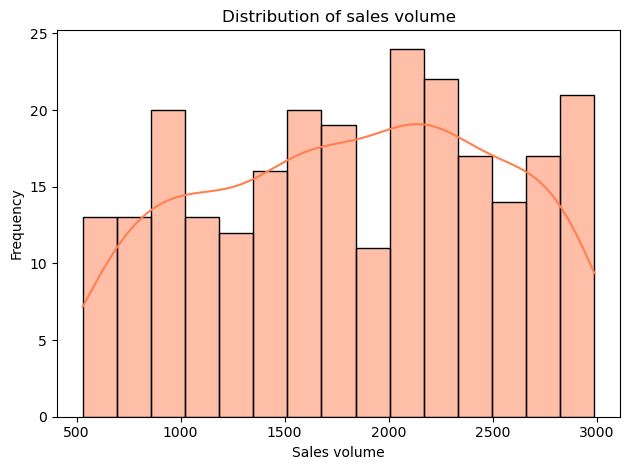

In [15]:
# Histogram of sales volumes

sns.histplot(data=df, x='sales volume', bins=15, color='coral', kde=True)
plt.title('Distribution of sales volume')
plt.xlabel('Sales volume')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

###### The range of sales per items go from 500+ to a little under 3000. Most products sell between 1500 to 2500.

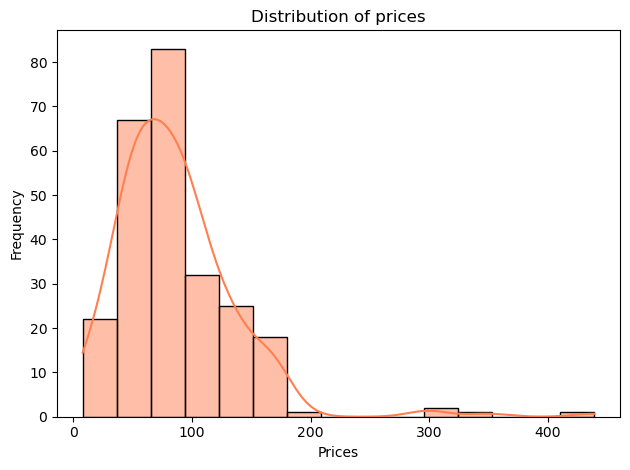

In [16]:
# Distribution of prices
sns.histplot(data=df, x='price',bins=15, color='coral', kde=True)
plt.title('Distribution of prices')
plt.xlabel('Prices')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

###### Most product prices are brtween 50 - 100

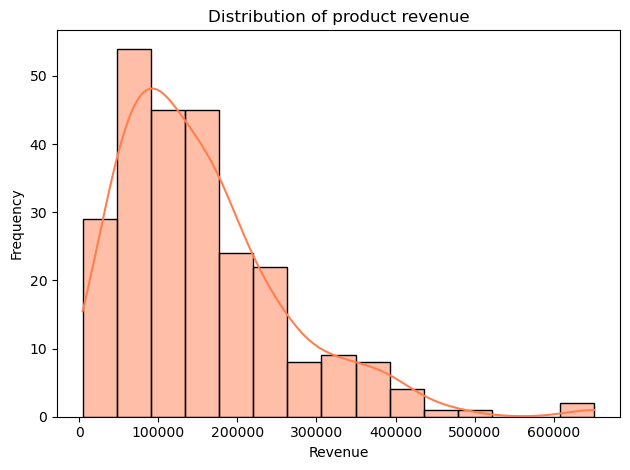

In [17]:
# Distribution of product revenue
sns.histplot(data=df, x='revenue',bins=15, color='coral', kde=True)
plt.title('Distribution of product revenue')
plt.xlabel('Revenue')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

###### Most product revenue are generated between 50000 - 200000

### Correlation analysis

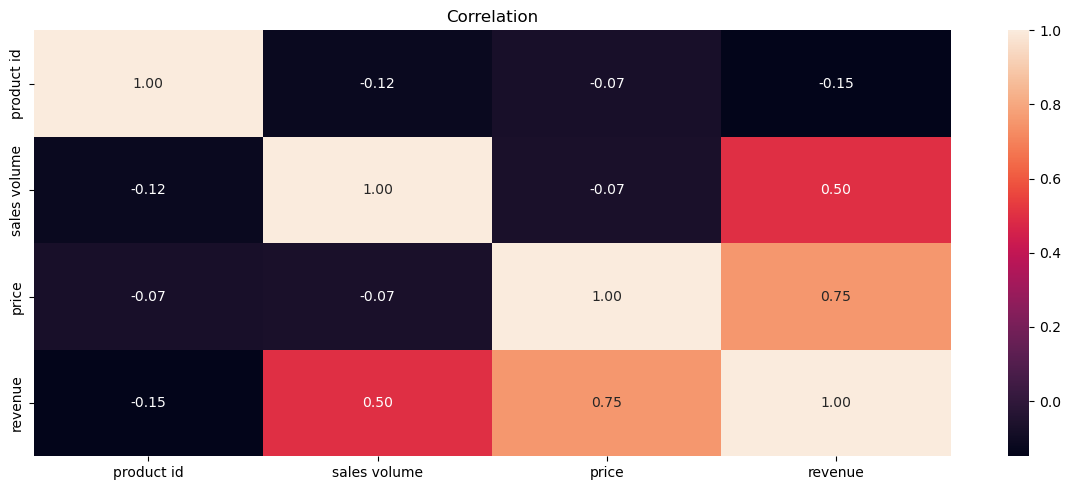

In [18]:
# Correlation analysis between numeric variable only
plt.figure(figsize=(12,5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='rocket', fmt='.2f')
plt.title('Correlation')
plt.tight_layout()
plt.show()

###### There is a strong and positive correlaton between product prices and revenue. Sales volume and revenue have a moderate correlation while prices and sales volume do not show any correlation.

### Bivariate analysis

C:\Users\WIN10\AppData\Local\Temp\ipykernel_9780\745975376.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='seasonal', y='price', palette='rocket', ax=axes[0])
C:\Users\WIN10\AppData\Local\Temp\ipykernel_9780\745975376.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='promotion', y='price', palette='rocket', ax=axes[1])


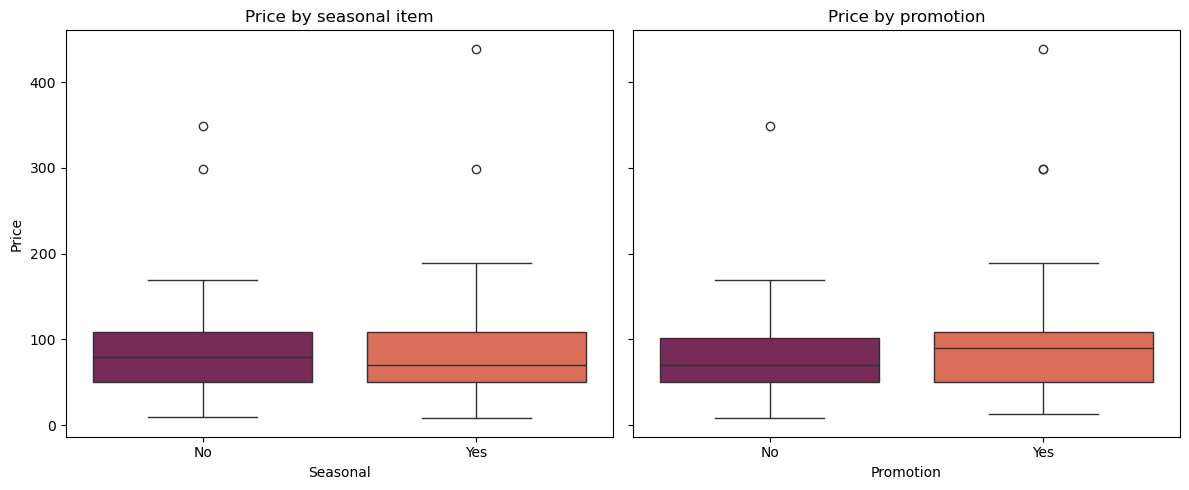

In [19]:
# Checking if there are outliers by price variable

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12,5), sharey=True)

# Chart 1
sns.boxplot(data=df, x='seasonal', y='price', palette='rocket', ax=axes[0])
axes[0].set_title('Price by seasonal item')
axes[0].set_xlabel('Seasonal')
axes[0].set_ylabel('Price')

# Chart 2
sns.boxplot(data=df, x='promotion', y='price', palette='rocket', ax=axes[1])
axes[1].set_title('Price by promotion')
axes[1].set_xlabel('Promotion')
axes[1].set_ylabel('Price')

fig.tight_layout()
plt.show()

In [20]:
# Finding outlier in prices

# Finding the 1st quantile and 3rd quantile for price
q1 = df['price'].quantile(0.25)
q3 = df['price'].quantile(0.75)

# Finding the interquantile
iqr_val = q3-q1

# Checking the upper and lower
lower_threshold = q1 - 1.5 * iqr_val
upper_threshold = q3 + 1.5 * iqr_val

outlier = df[(df['price']<lower_threshold) | (df['price']>upper_threshold)]
print(outlier)

    product id product position promotion seasonal  sales volume  \
13      151396   Front of Store       Yes      Yes           729   
22      161909            Aisle       Yes       No          1290   
38      114877            Aisle        No       No          1860   
60      151925          End-cap       Yes      Yes          2179   

                                    name  price    terms section   revenue  \
13                cropped leather jacket  439.0  jackets     man  320031.0   
22                        leather jacket  299.0  jackets     man  385710.0   
38                          suede jacket  349.0  jackets     man  649140.0   
60  vintage effect leather bomber jacket  299.0  jackets     man  651521.0   

   price_category  
13         Luxury  
22         Luxury  
38         Luxury  
60         Luxury  


###### The outliers identified are prices from jackets. The material in common of these jackets is leather. Suede - which is a soft type of leather - has the second highest price, behind a cropped leather jacket which has a price of USD 439.

C:\Users\WIN10\AppData\Local\Temp\ipykernel_9780\3957071099.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='seasonal', y='sales volume', palette='rocket', ax=axes[0])
C:\Users\WIN10\AppData\Local\Temp\ipykernel_9780\3957071099.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='promotion', y='sales volume', palette='rocket', ax=axes[1])


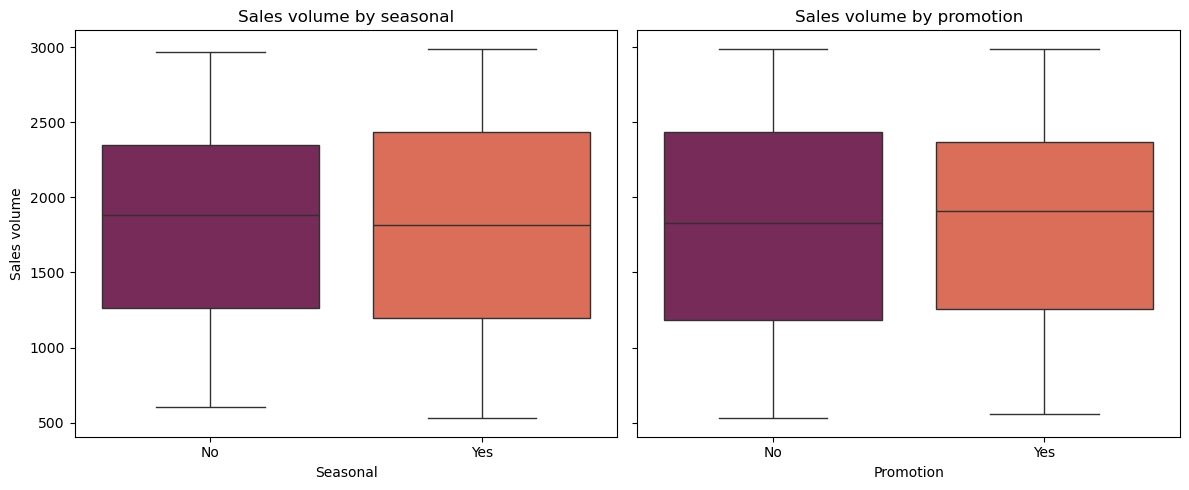

In [21]:
# Checking if there are outliers in sales volumes

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12,5), sharey=True)

# Chart 1
sns.boxplot(data=df, x='seasonal', y='sales volume', palette='rocket', ax=axes[0])
axes[0].set_title('Sales volume by seasonal')
axes[0].set_xlabel('Seasonal')
axes[0].set_ylabel('Sales volume')

# Chart 2
sns.boxplot(data=df, x='promotion', y='sales volume', palette='rocket', ax=axes[1])
axes[1].set_title('Sales volume by promotion')
axes[1].set_xlabel('Promotion')
axes[1].set_ylabel('Sales volume')

fig.tight_layout()
plt.show()

In [22]:
# Finding outliers in sales volume

q1_sls = df['sales volume'].quantile(0.25)
q2_sls = df['sales volume'].quantile(0.75)

iqr_val_sls = q2_sls - q1_sls
lower_threshold_sls = q1_sls - 1.5 * iqr_val_sls
upper_threshold_sls = q2_sls + 1.5 * iqr_val_sls

outlier_sls = df[(df['sales volume']<lower_threshold_sls) | (df['sales volume']>upper_threshold_sls)]
print(outlier_sls)

Empty DataFrame
Columns: [product id, product position, promotion, seasonal, sales volume, name, price, terms, section, revenue, price_category]
Index: []


## Segmentation analysis

C:\Users\WIN10\AppData\Local\Temp\ipykernel_9780\1622249889.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='section', y='sales volume', estimator=sum, palette='rocket', ax=axes[0,0])
C:\Users\WIN10\AppData\Local\Temp\ipykernel_9780\1622249889.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='promotion', y='sales volume', estimator=sum, palette='rocket', ax=axes[0,1])
C:\Users\WIN10\AppData\Local\Temp\ipykernel_9780\1622249889.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='seasonal', y='sales v

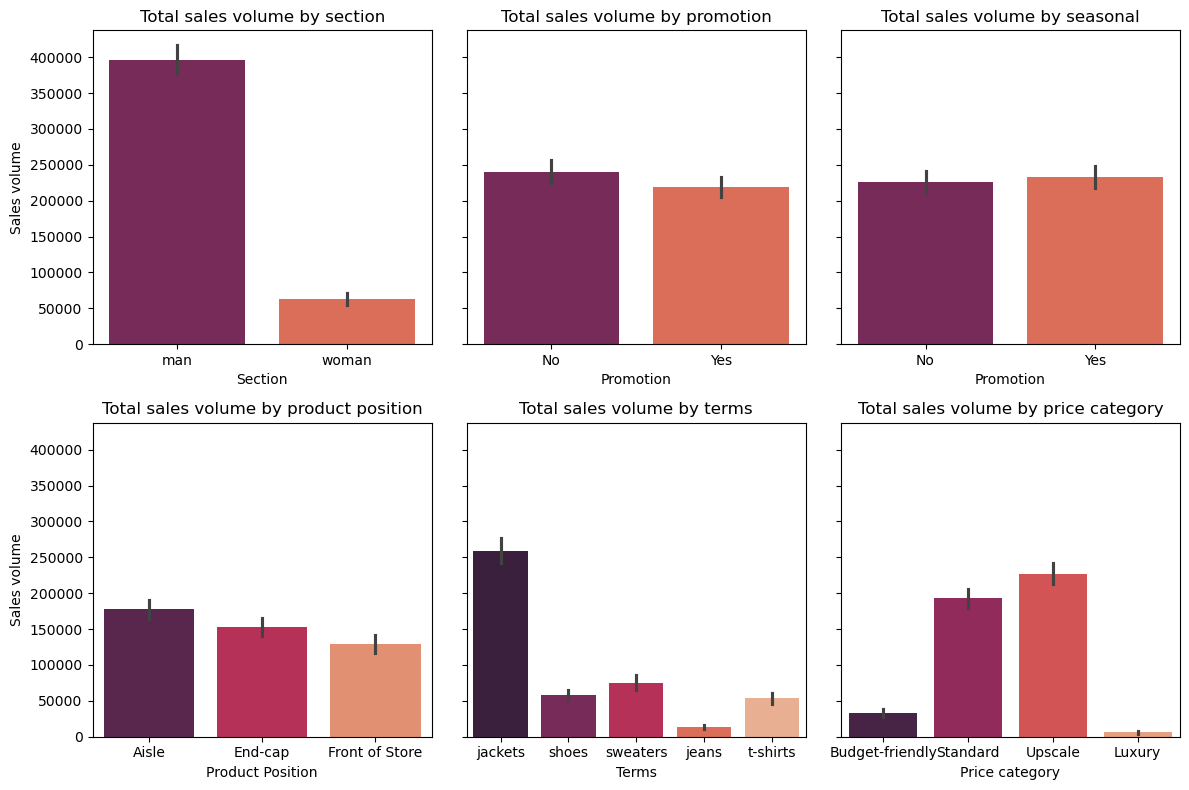

In [23]:
# Analyzing result for total sales volyme by diff categories

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(12,8), sharey=True)
# Chart 1
sns.barplot(data=df, x='section', y='sales volume', estimator=sum, palette='rocket', ax=axes[0,0])
axes[0,0].set_title('Total sales volume by section')
axes[0,0].set_xlabel('Section')
axes[0,0].set_ylabel('Sales volume')

# Chart 2
sns.barplot(data=df, x='promotion', y='sales volume', estimator=sum, palette='rocket', ax=axes[0,1])
axes[0,1].set_title('Total sales volume by promotion')
axes[0,1].set_xlabel('Promotion')
axes[0,1].set_ylabel('Sales volume')

# Chart 3
sns.barplot(data=df, x='seasonal', y='sales volume', estimator=sum, palette='rocket', ax=axes[0,2])
axes[0,2].set_title('Total sales volume by seasonal')
axes[0,2].set_xlabel('Promotion')
axes[0,2].set_ylabel('Sales volume')

# Chart 4
sns.barplot(data=df, x='product position', y='sales volume', estimator=sum, palette='rocket', ax=axes[1,0])
axes[1,0].set_title('Total sales volume by product position')
axes[1,0].set_xlabel('Product Position')
axes[1,0].set_ylabel('Sales volume')

# Chart 5
sns.barplot(data=df, x='terms', y='sales volume', estimator=sum, palette='rocket', ax=axes[1,1])
axes[1,1].set_title('Total sales volume by terms')
axes[1,1].set_xlabel('Terms')
axes[1,1].set_ylabel('Sales volume')

# Chart 6
sns.barplot(data=df, x='price_category', y='sales volume', estimator=sum, palette='rocket', ax=axes[1,2])
axes[1,2].set_title('Total sales volume by price category')
axes[1,2].set_xlabel('Price category')
axes[1,2].set_ylabel('Sales volume')

fig.tight_layout()
plt.show()

###### The men's section outperformed women's by over 200K in sales volume. Seasonal and basic clothing show relatively consistent sales volume. Items not on promotion had slightly higher performance than those on promotion. Sales volume by product position shows that aisle and end-cap positions had the highest sales while the front of store had the lowest. Jackets were the best selling products with over 250 K units sold, followed by sweaters; meanwhile, jeans had the least sales with less than 50K units sold. Products under the upscale and standard price category have the highest sales volume.

C:\Users\WIN10\AppData\Local\Temp\ipykernel_9780\2805662272.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df,x="section",y='sales volume',estimator=np.mean,palette="rocket",ax=axes[0,0])
C:\Users\WIN10\AppData\Local\Temp\ipykernel_9780\2805662272.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\WIN10\AppData\Local\Temp\ipykernel_9780\2805662272.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\WIN10\AppData\Local\Temp\ipykernel_9780\2805662272.py:24: FutureWarning: 

Passing `palette` without assigning `

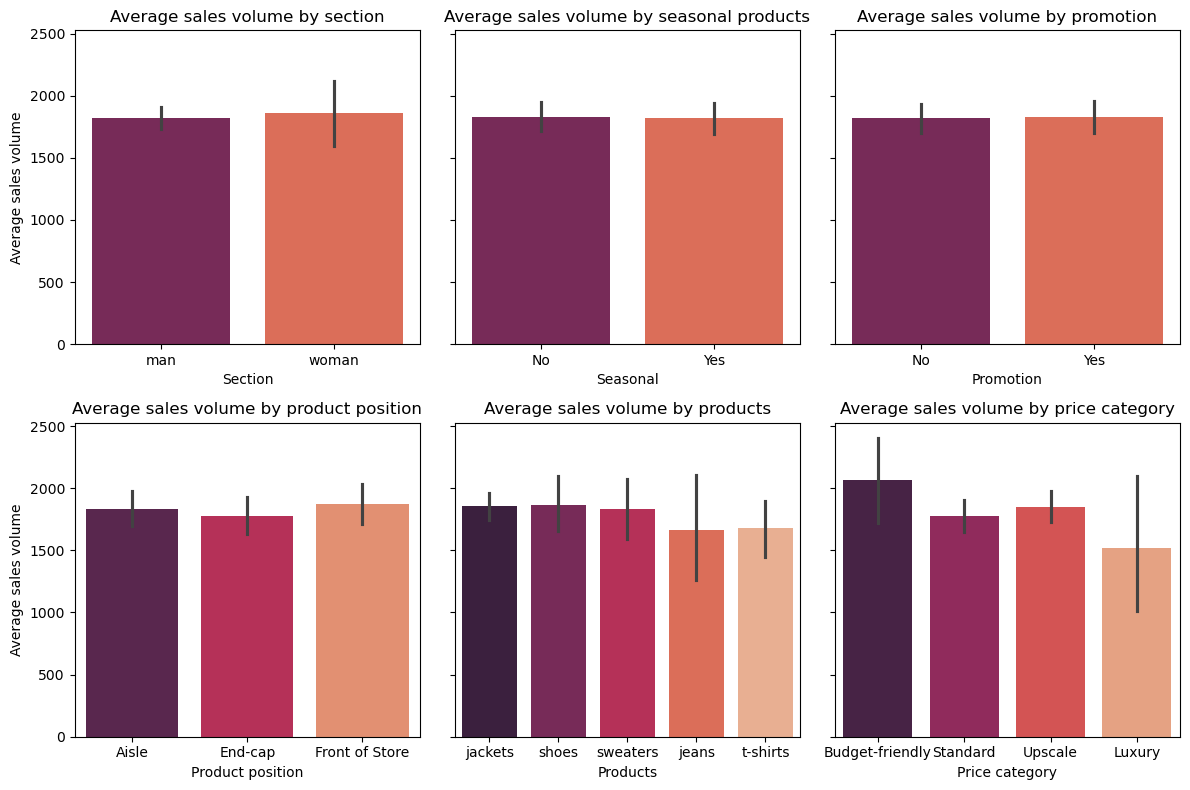

In [24]:
# Assessing effectiveness of diferent categories
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(12, 8), sharey=True)
# Chart 1: 
sns.barplot(data=df,x="section",y='sales volume',estimator=np.mean,palette="rocket",ax=axes[0,0])
axes[0,0].set_title("Average sales volume by section")
axes[0,0].set_xlabel("Section")
axes[0,0].set_ylabel("Average sales volume")

# Chart 2:
sns.barplot(
    data=df,x="seasonal",y='sales volume',estimator=np.mean,palette="rocket",ax=axes[0,1])
axes[0,1].set_title("Average sales volume by seasonal products")
axes[0,1].set_xlabel("Seasonal")
axes[0,1].set_ylabel("") 

# Chart 3:
sns.barplot(
    data=df,x="promotion",y='sales volume',estimator=np.mean,palette="rocket",ax=axes[0,2])
axes[0,2].set_title("Average sales volume by promotion")
axes[0,2].set_xlabel("Promotion")
axes[0,2].set_ylabel("")

# Chart 4
sns.barplot(
    data=df,x="product position",y="sales volume",estimator=np.mean,palette="rocket",ax=axes[1,0])
axes[1,0].set_title("Average sales volume by product position")
axes[1,0].set_xlabel("Product position")
axes[1,0].set_ylabel("Average sales volume") 

# Chart 5
sns.barplot(
    data=df,x="terms",y="sales volume",estimator=np.mean,palette="rocket",ax=axes[1,1])
axes[1,1].set_title("Average sales volume by products")
axes[1,1].set_xlabel("Products")
axes[1,1].set_ylabel("") 

# Chart 6
sns.barplot(
    data=df,x="price_category",y="sales volume",estimator=np.mean,palette="rocket",ax=axes[1,2])
axes[1,2].set_title("Average sales volume by price category")
axes[1,2].set_xlabel("Price category")
axes[1,2].set_ylabel("") 

fig.tight_layout()
plt.show()

###### The charts indicate that there is no significant difference in average sales volume between men and women's section, seasonal and non-seasonal items, nor between products on promotion and those not on promotion.Regarding product position, items located at the front of the store show a slightly higher average sales volume compared to those placed in aisles or on end-caps. Jackets, shoes and sweaters show a similar sales pattern - outselling jeans and t-shirts by a small margin. Budget-friendly items sold an average of 2K+ items, followed by upscale and standard products (1.8K-1.9K) and lastly, luxury items sold on average around 1.5K items.

C:\Users\WIN10\AppData\Local\Temp\ipykernel_9780\2292455223.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df,x="section",y="revenue",estimator=sum,palette="rocket",ax=axes[0,0])
C:\Users\WIN10\AppData\Local\Temp\ipykernel_9780\2292455223.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\WIN10\AppData\Local\Temp\ipykernel_9780\2292455223.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\WIN10\AppData\Local\Temp\ipykernel_9780\2292455223.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is d

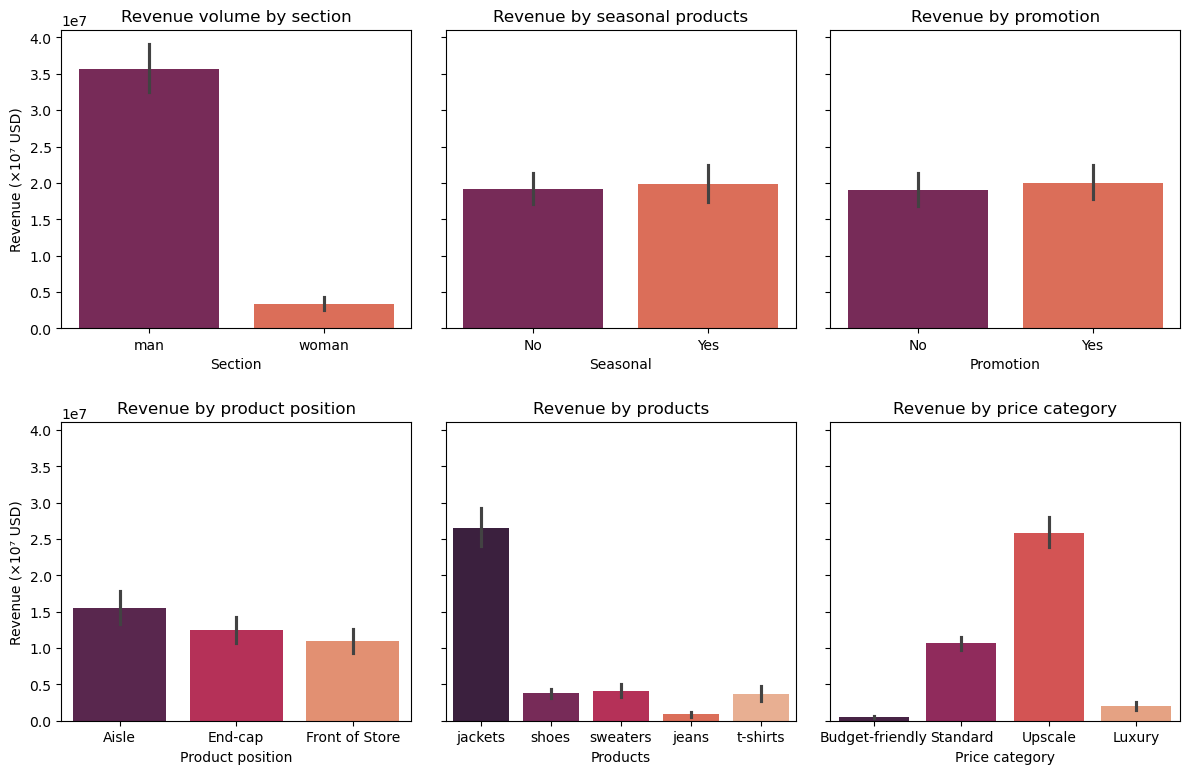

In [25]:
# Reviewing total revenue by each category
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(12, 8), sharey=True)
# Chart 1: 
sns.barplot(data=df,x="section",y="revenue",estimator=sum,palette="rocket",ax=axes[0,0])
axes[0,0].set_title("Revenue volume by section")
axes[0,0].set_xlabel("Section")
axes[0,0].set_ylabel("Revenue (×10⁷ USD)")

# Chart 2:
sns.barplot(
    data=df,x="seasonal",y="revenue",estimator=sum,palette="rocket",ax=axes[0,1])
axes[0,1].set_title("Revenue by seasonal products")
axes[0,1].set_xlabel("Seasonal")
axes[0,1].set_ylabel("") 

# Chart 3:
sns.barplot(
    data=df,x="promotion",y="revenue",estimator=sum,palette="rocket",ax=axes[0,2])
axes[0,2].set_title("Revenue by promotion")
axes[0,2].set_xlabel("Promotion")
axes[0,2].set_ylabel("")

# Chart 4
sns.barplot(
    data=df,x="product position",y="revenue",estimator=sum,palette="rocket",ax=axes[1,0])
axes[1,0].set_title("Revenue by product position")
axes[1,0].set_xlabel("Product position")
axes[1,0].set_ylabel("Revenue (×10⁷ USD)")

# Chart 5
sns.barplot(
    data=df,x="terms",y="revenue",estimator=sum,palette="rocket",ax=axes[1,1])
axes[1,1].set_title("Revenue by products")
axes[1,1].set_xlabel("Products")
axes[1,1].set_ylabel("") 

# Chart 6
sns.barplot(
    data=df,x="price_category",y="revenue",estimator=sum,palette="rocket",ax=axes[1,2])
axes[1,2].set_title("Revenue by price category")
axes[1,2].set_xlabel("Price category")
axes[1,2].set_ylabel("") 

fig.tight_layout()
plt.show()

###### Jackets are the highest grossing clothing product with over USD 26M. Sweaters had the second best performance with a revenue of USD 4M. Both t-shirts and shoes had a similar performance, obtaining USD 3M in revenue. Jeans had the lowest revenue with just above USD 8.5K. 

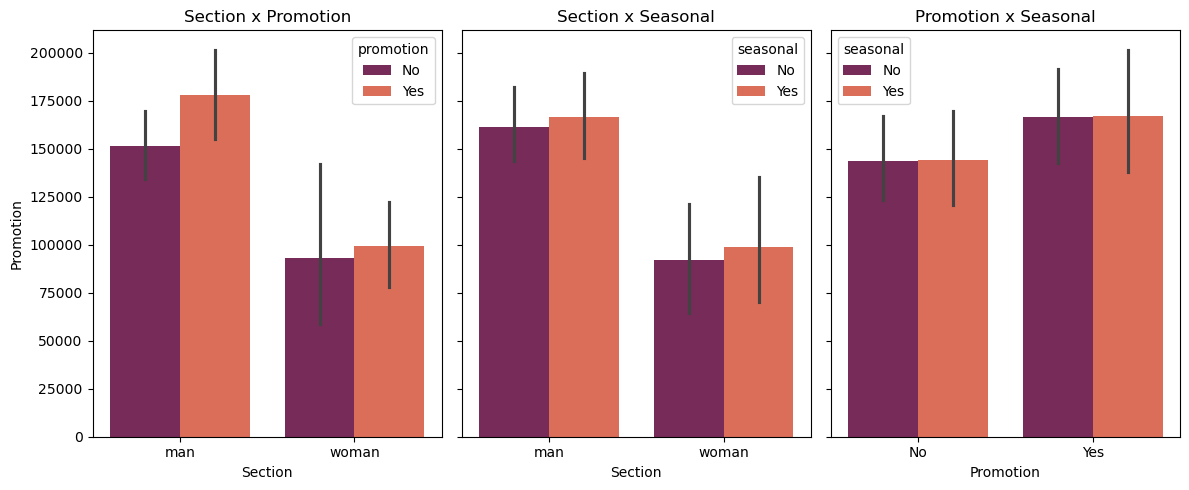

In [26]:
# Key varirable comparisson
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(12,5), sharey=True)

# Chart 1
sns.barplot(data=df, x='section', y='revenue', hue='promotion', palette='rocket', ax=axes[0])
axes[0].set_title('Section x Promotion')
axes[0].set_xlabel('Section')
axes[0].set_ylabel('Promotion')

# Chart 2
sns.barplot(data=df, x='section', y='revenue', hue='seasonal', palette='rocket', ax=axes[1])
axes[1].set_title('Section x Seasonal')
axes[1].set_xlabel('Section')
axes[1].set_ylabel('Seasonal')

# Chart 3
sns.barplot(data=df, x='promotion', y='revenue', hue='seasonal', palette='rocket', ax=axes[2])
axes[2].set_title('Promotion x Seasonal')
axes[2].set_xlabel('Promotion')
axes[2].set_ylabel('Seasonal')

fig.tight_layout()
plt.show()

###### Products in the men's section generate significantly higher revenue than those in the women's section. Promotions appear to have a stronger impact in the men's section, leading to higher sales. Seasonal products obtain slightly higher revenue in both sections than those non-seasonal products. Overall, promoted products perform better but the impact of promotions seems less dependent on whether an item is seasonal or not.

In [27]:
# Price category x section: sales volume, revenue and price average
df.groupby(['price_category', 'section'], observed=True).agg(
    sales_volume = ('sales volume', 'sum'),
    avg_price = ('price', 'mean'),
    revenue_sum = ('revenue', 'sum'),
    count = ('section', 'count')
).reset_index()

,price_category,section,sales_volume,avg_price,revenue_sum,count
0,Budget-friendly,man,29812,16.548571,480546.74,14
1,Budget-friendly,woman,3285,7.990000,26247.15,2
2,Standard,man,137392,57.902278,7971994.09,79
3,Standard,woman,55781,48.433333,2676191.90,30
4,Upscale,man,222937,114.262810,25253720.20,121
5,Upscale,woman,4308,124.450000,573374.40,2
6,Luxury,man,6058,346.500000,2006402.00,4


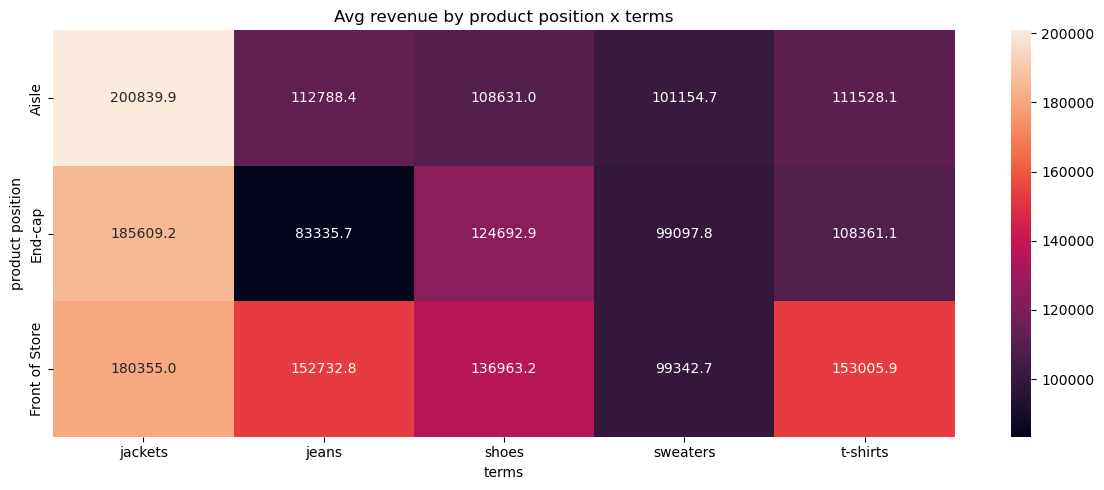

In [28]:
# Heatmap product position x terms
df_terms_loc = df.pivot_table(index='product position', columns='terms', values='revenue', aggfunc='mean')

plt.figure(figsize=(12,5))
sns.heatmap(df_terms_loc, cmap='rocket', annot=True, fmt='.1f')
plt.title('Avg revenue by product position x terms')

plt.tight_layout()
plt.show()

###### Jackets had the highest revenue on average across the store, surpassing the overall revenue average (USD 154,716.17). The products that had a consistent low performance in the store were sweaters. 

###### Shoes and t-shirts exceeded USD 100K on revenue in the different areas -  suggesting a good and balanced performance throughout. 

###### Lastly, revenue from jeans sales varied across the three positions:  ront-of-store placement had the highest revenue (USD 152K+), closely followed by aisle position (USD 112K+) while placement at the end-cap had the lowest revenue (less than USD 85K).

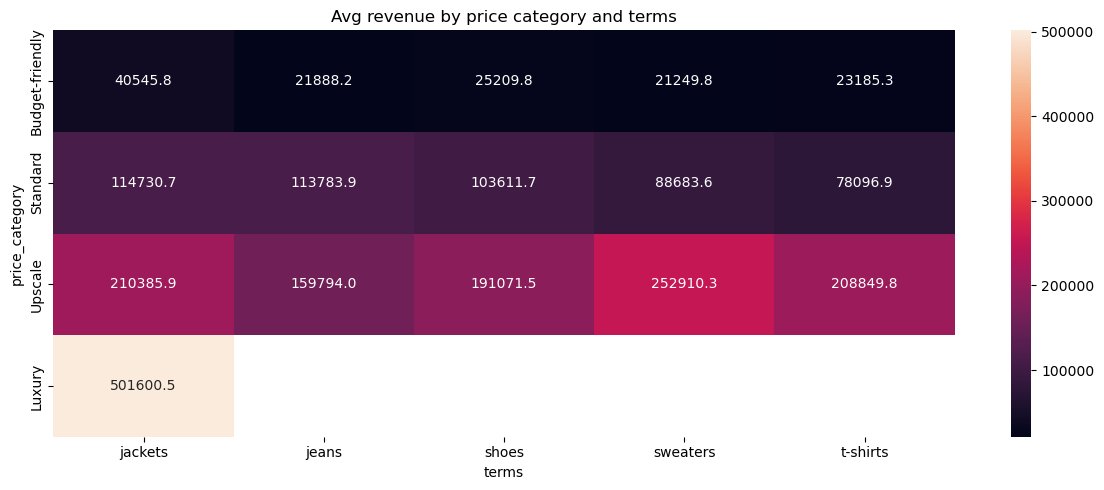

In [29]:
# Heatmap of revenue by price category x terms
def_rev_price = df.pivot_table(index='price_category', columns='terms', values='revenue', aggfunc='mean')

plt.figure(figsize=(12,5))
sns.heatmap(def_rev_price, cmap='rocket', annot=True, fmt='.1f')
plt.title('Avg revenue by price category and terms')

plt.tight_layout()
plt.show()

###### Luxury jackets had a revenue of more than 3 times the average - making these products great values for the Zara catalog. Products under the *Upscale* category all had an excellent performance, exceeding the overall average revenue. It's worth noting that upscale sweaters have the second best average revenue after luxury jackets. 

###### In contrast, all products in the Standard category showed moderate performance, with average revenues ranging from USD 78K to USD 114K. Items under the Budget-friendly category recorded the lowest revenue across all product types.

###### The results suggest customers prefer higher-priced products over the budget friendly products, which could be due to a perceived value or quality of the items.

Text(0.5, 0.98, 'Sales volume VS Revenue by Product, Price Category and Price Position')

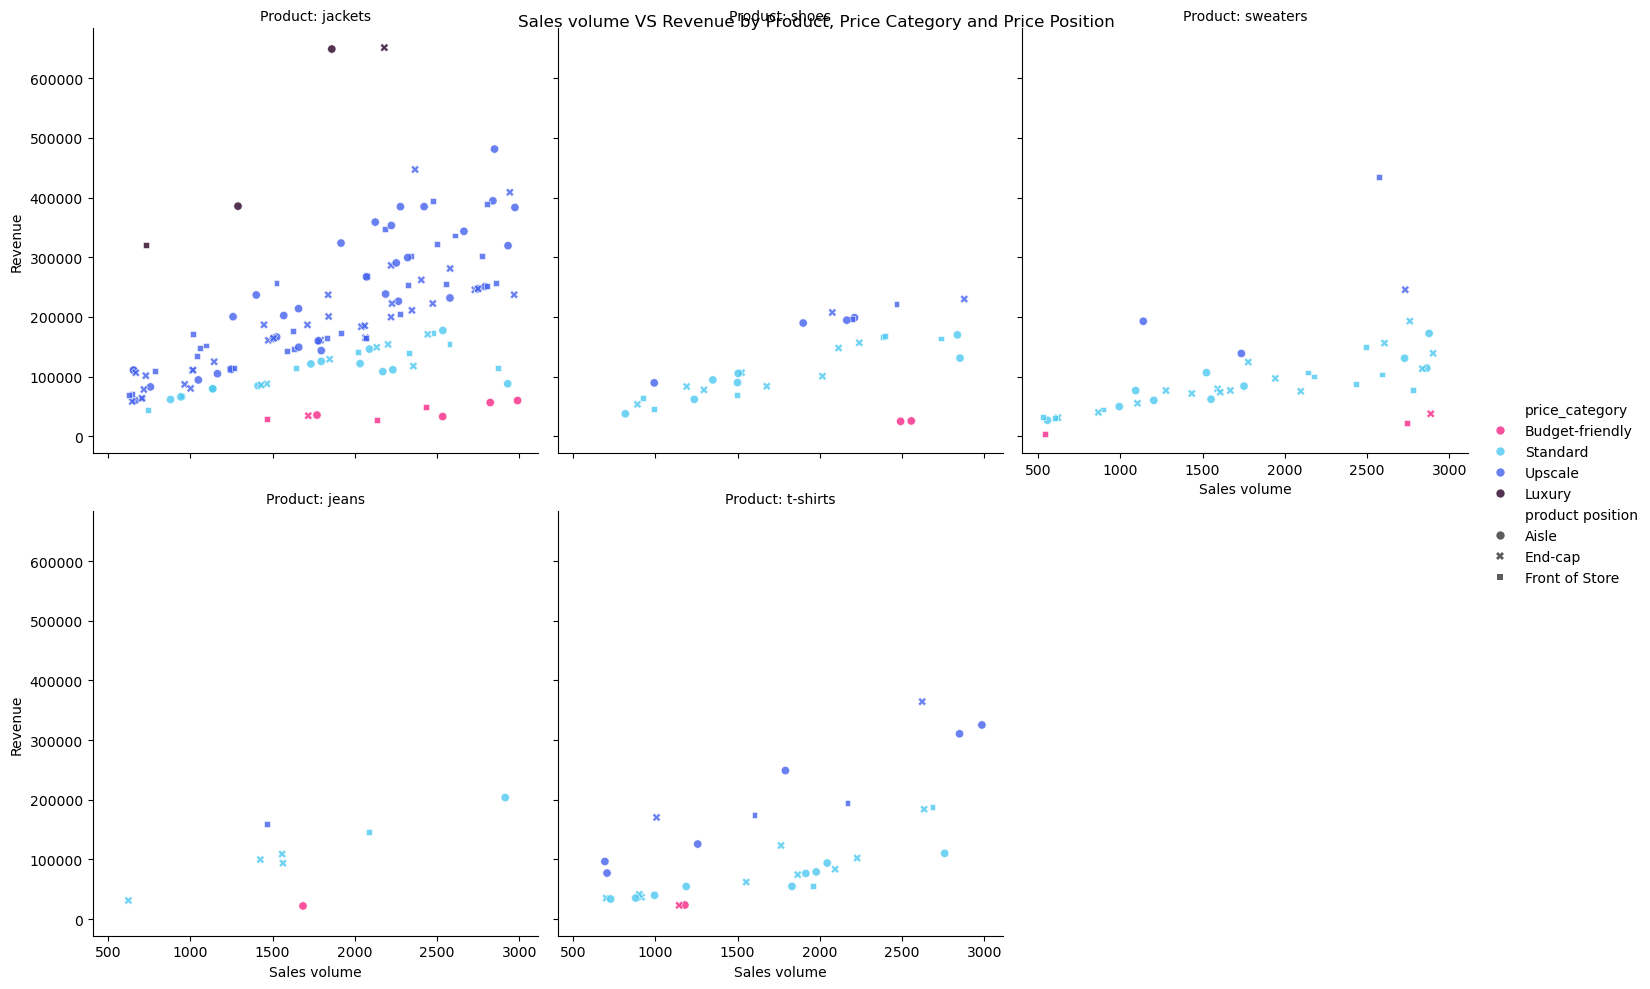

In [31]:
# Relationship between sales volume x revenue and product , price category and product position

palette = ["#F72585","#4CC9F0","#4361EE","#290025"]

g = sns.relplot(data=df, x='sales volume', y='revenue', col='terms', col_wrap=3,
               style='product position', hue='price_category', alpha=0.8, palette=palette)

g.set_axis_labels('Sales volume', 'Revenue')
g.set_titles(col_template='Product: {col_name}')
g.fig.suptitle('Sales volume VS Revenue by Product, Price Category and Price Position')


###### All different products had an increase in revenue as more items were sold. Jackets had a constant growth and good performance throughout the store, with upscale jackets getting the most units solds in all placements. Luxury jackets varied -  with products reaching USD 300K+ with less than 1K units sold, and others obtaining USD 600K with twice the sales volume. Standard jackets had a steady growth, although they had less revenue. Budget-friendly jackets remained under USD 100K despite having a continuos growth in sales volume. 

###### Shoes and sweaters show a similar pattern: most standard items had a growing sales volume, bringing less than USD 200K. Likewise, while there were more upscale products in the shoes department, the revenue was somewhat similar to sweaters. Upscale items in end-cap placement sold around the same number of units sold and brought it revenue of USD 200K-250K.

###### Jeans had standard items placed in the end-cap store getting more revenure while those at the front and aisles had higher unit sales. Even though upscale jeans sold less units than budget-friendly products, these had a revenue of almost USD 200K.

###### Finally, t-shirts achieved higher sales in upscale items than those under the standard category. Items placed aisles had most sales than when located in end-cap or front of store.

## Best and Worst performer

C:\Users\WIN10\AppData\Local\Temp\ipykernel_9780\903042847.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10, x='revenue', y='name', palette='flare')


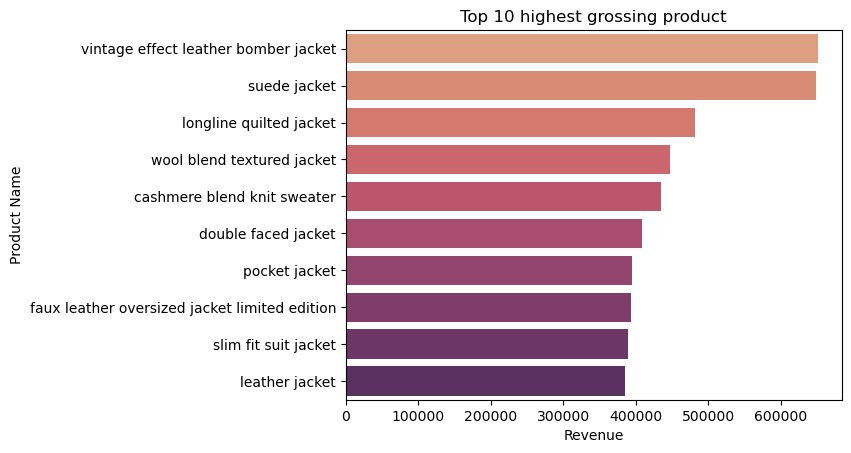

In [32]:
# Top 10 highest grossing product
top_10 = df.sort_values('revenue', ascending=False).iloc[:10]

sns.barplot(data=top_10, x='revenue', y='name', palette='flare')
plt.title('Top 10 highest grossing product')
plt.xlabel('Revenue')
plt.ylabel('Product Name')
plt.show()

###### Most highest-grossing products are jackets, with vintage effect leather and suede jackets being the top 2 products that generated over USD 600,000.

C:\Users\WIN10\AppData\Local\Temp\ipykernel_9780\1097479021.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_sales, x='sales volume', y='name', palette='flare')


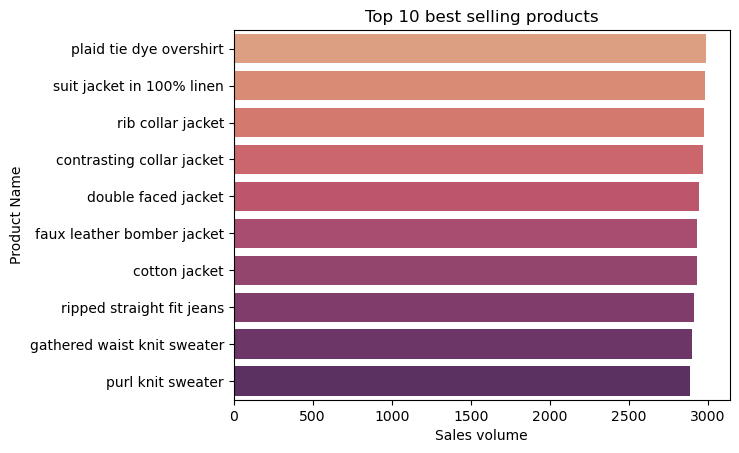

In [33]:
# Top 10 best selling products

top_10_sales = df.sort_values('sales volume', ascending=False).iloc[:10]

sns.barplot(data=top_10_sales, x='sales volume', y='name', palette='flare')
plt.title('Top 10 best selling products')
plt.xlabel('Sales volume')
plt.ylabel('Product Name')
plt.show()

###### The ten best-selling products from Zara are a variety of items, from sweaters and jeans to jackets and an overshirt. All of these products sold over 2,500 units individually.

C:\Users\WIN10\AppData\Local\Temp\ipykernel_9780\2729128584.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10, x='revenue',y='name', palette='rocket')


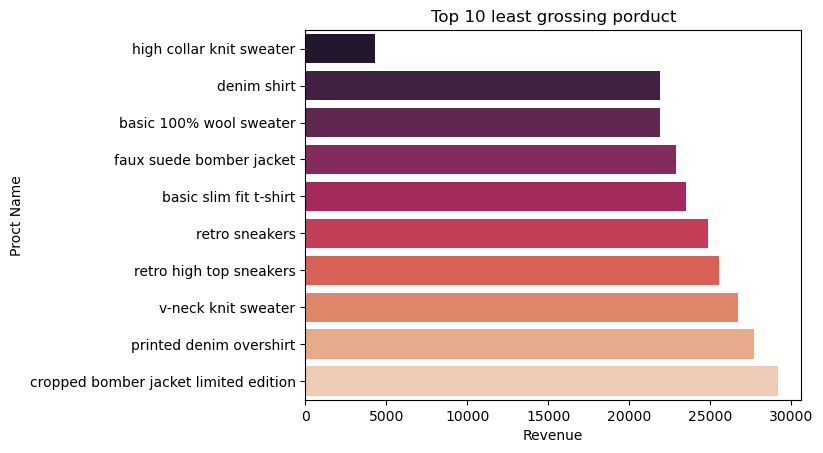

In [37]:
# Top 10 least grossing products
top_10 = df.sort_values('revenue', ascending=True).iloc[:10]

sns.barplot(data=top_10, x='revenue',y='name', palette='rocket')
plt.title('Top 10 least grossing porduct')
plt.xlabel('Revenue')
plt.ylabel('Proct Name')
plt.show()

C:\Users\WIN10\AppData\Local\Temp\ipykernel_9780\2550206849.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bottom_10_sales,x="sales volume",y="name",palette="rocket")


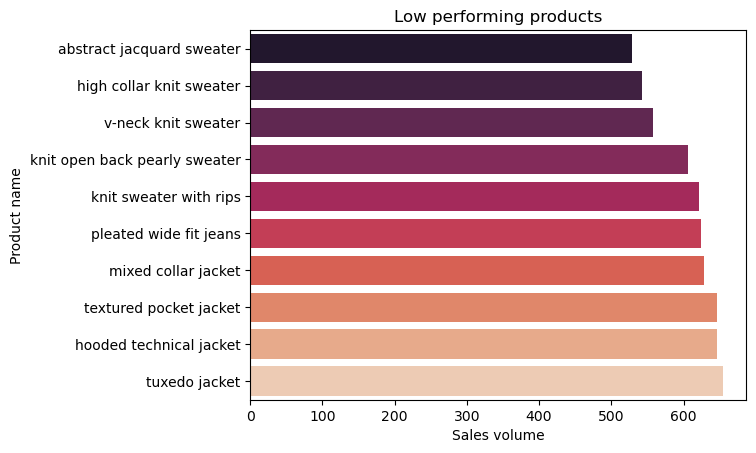

In [36]:
# Ten lowest performing products

bottom_10_sales = df.sort_values("sales volume", ascending=True).iloc[:10]

sns.barplot(data=bottom_10_sales,x="sales volume",y="name",palette="rocket")
plt.title("Low performing products")
plt.ylabel("Product name")
plt.xlabel("Sales volume")
plt.show()